# Assisgnment 1 - Group 75

Let's start by importing the relevant python packages

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from datetime import datetime, time

Then we load the data

In [3]:
data = pd.read_csv(r"G:\My Drive\Skole\DTU\10. semester\02806 Social_data_viz\10_sem\Data\2003_2026.csv")

In [4]:
data.head(2)

,Incident Category,Incident Datetime,Incident Day of Week,Incident Code,Incident Description,Police District,Longitude,Latitude
0,Robbery,2004-11-22 17:50:00,Monday,3074,"ROBBERY, BODILY FORCE",Ingleside,-122.420084,37.708311
1,Motor Vehicle Theft,2005-10-18 20:00:00,Tuesday,7021,STOLEN AUTOMOBILE,Park,-120.500000,90.000000


We remember to fix the datetime format

In [5]:
data['Incident Datetime'] = pd.to_datetime(data['Incident Datetime'])

Then we hone in on our focus crimes

In [6]:
focus_crimes = ['Robbery','Motor Vehicle Theft','Weapons Offense','Rape','Disorderly Conduct','Larceny Theft']
focus_data = data[data['Incident Category'].isin(focus_crimes)]

## 1.1

In [9]:
yearly_counts = focus_data['Incident Datetime'].dt.year.value_counts()
print(yearly_counts)

Incident Datetime
2018    79100
2019    61875
2017    59630
2022    57712
2015    56516
2023    54958
2016    53057
2021    52258
2014    50864
2005    49477
2013    49060
2004    48069
2003    47262
2020    44249
2012    43587
2006    40770
2024    39727
2008    38889
2007    38644
2009    37023
2011    36209
2010    34576
2025    29857
Name: count, dtype: int64


In [8]:
focus_counts = focus_data[focus_data['Incident Category'].isin(focus_crimes)]
focus_counts['Incident Category'].value_counts()

Incident Category
Larceny Theft          771237
Motor Vehicle Theft    181131
Robbery                 76951
Weapons Offense         34127
Disorderly Conduct      30913
Rape                     9010
Name: count, dtype: int64

In [ ]:
yearly_counts_per_crime = focus_counts.groupby(['Incident Category', 'Incident Year']).size().reset_index(name='Count')

# 2. Get the list of unique categories
categories = sorted(yearly_counts_per_crime['Incident Category'].unique())
num_categories = len(categories)

# 3. Define the grid size
cols = 4
rows = (num_categories // cols) + (1 if num_categories % cols != 0 else 0)


SyntaxError: unterminated string literal (detected at line 1) (4281624498.py, line 1)

In [ ]:
yearly_counts_per_crime

,Incident Category,Incident Year,Count
0,Arson,2018,363
1,Arson,2019,307
2,Arson,2020,421
3,Arson,2021,430
4,Arson,2022,399
...,...,...,...
123,Weapons Offense,2021,1098
124,Weapons Offense,2022,1042
125,Weapons Offense,2023,1060
126,Weapons Offense,2024,921


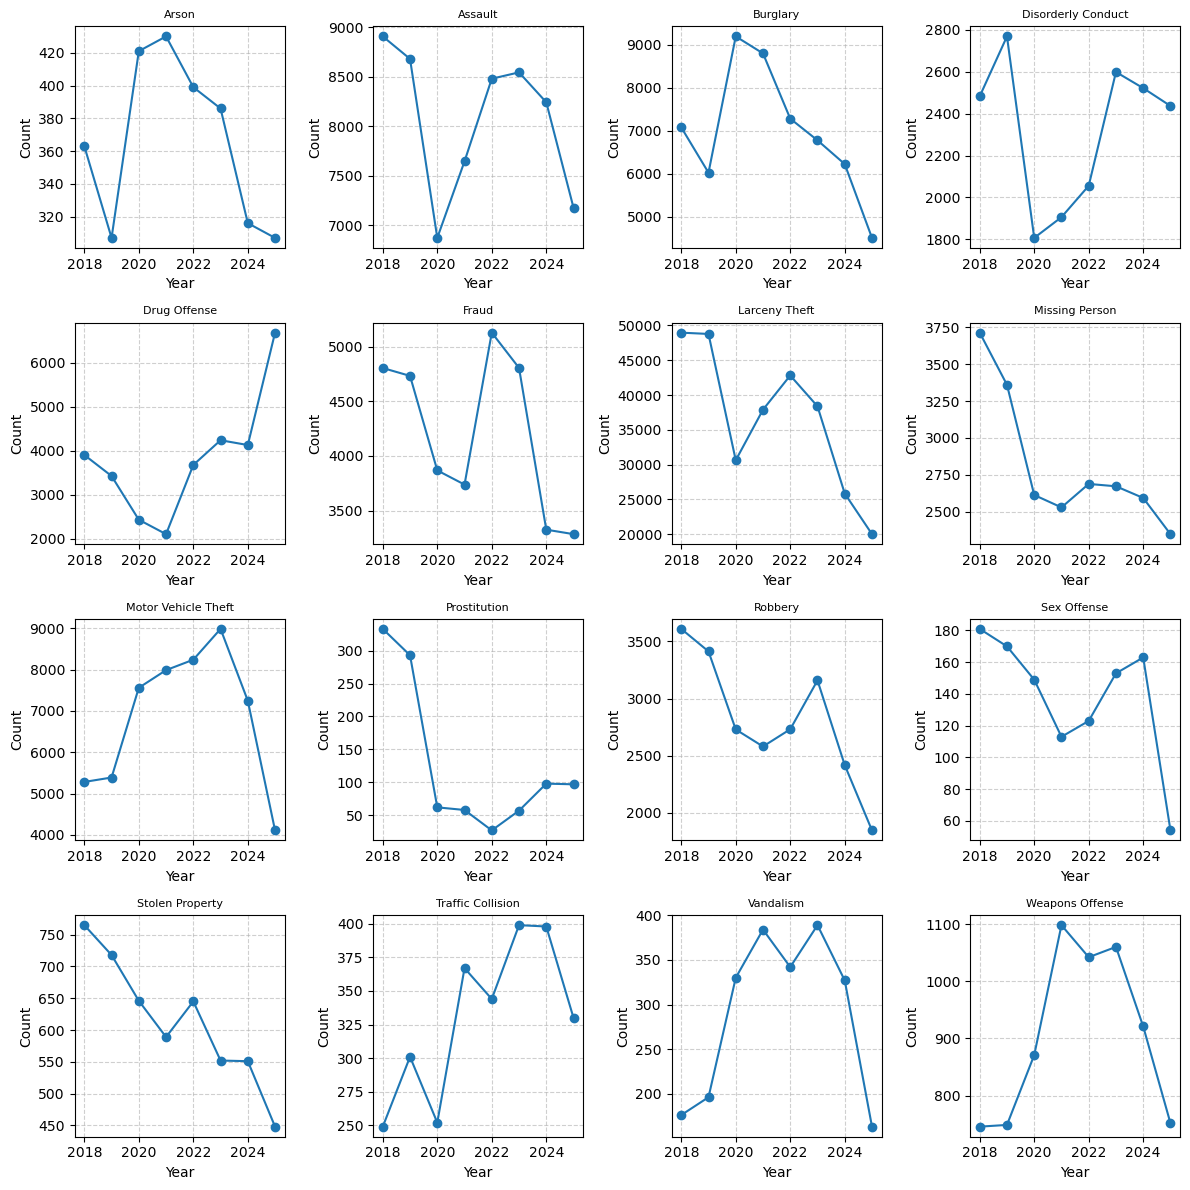

In [ ]:
fig, axes = plt.subplots(4, rows, figsize=(12, 12))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration
for i, category in enumerate(categories):
    ax = axes[i]
    # Filter data for this specific category
    category_data = yearly_counts_per_crime[yearly_counts_per_crime['Incident Category'] == category]
    
    # Plotting
    ax.plot(category_data['Incident Year'], category_data['Count'], marker='o', linestyle='-', color='tab:blue')
        # Customizing the individual subplot
    ax.set_title(category, fontsize=8)
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')
    ax.grid(True, linestyle='--', alpha=0.6)
# 6. Final layout adjustments
plt.tight_layout()
plt.show()